In [1]:
import subprocess
import re
import pandas as pd
import matplotlib.pyplot as plt
import os

# 序列长度

In [2]:
# 可执行程序路径
EXECUTABLE = "../anchor_mapping"

# sweep 范围
truncate_values = range(100000, 1000000, 200000)

results = []

for tlen in truncate_values:
    print(f"Running with truncate_ref_len = {tlen}...")
    cmd = [
        EXECUTABLE,
        "--num_anchors", "50",
        "--truncate_ref_len", str(tlen),
        "--anchor_len", "20",
        "--num_queries", "100",
        "--maxDist", "3",
        "--leaf_radius_threshold", "6",
        "--compactness_min_capacity", "8",
        "--compactness_radius_factor", "1.1"
    ]

    proc = subprocess.run(cmd, capture_output=True, text=True)

    if proc.returncode != 0:
        print(f"Error running {cmd}: {proc.stderr}")
        continue

    output = proc.stdout

    # 提取时间指标
    metrics = {}
    patterns = {
        "read_time":     r"Read FASTQA file time:(\d+)",
        "tree_time":     r"Build Tree time:(\d+)",
        "overlap_time":  r"Calculate overlap time:(\d+)",
        "truth_time":    r"Get ground truth time:(\d+)",
        "query_time":    r"Query time:(\d+)",
    }

    for key, pat in patterns.items():
        m = re.search(pat, output)
        if m:
            metrics[key] = int(m.group(1))
        else:
            print(f"⚠️ {key} not found in output for truncate_ref_len={tlen}")
            metrics[key] = None

    metrics["truncate_ref_len"] = tlen
    results.append(metrics)

# 转 DataFrame
df = pd.DataFrame(results)
print(df)

# 保存结果
df.to_csv("./csv/sweep_results_truncate_time.csv", index=False)

# 画图（每个阶段一个曲线）
plt.figure(figsize=(8,5))
for col in ["read_time", "tree_time", "overlap_time", "truth_time", "query_time"]:
    plt.plot(df["truncate_ref_len"], df[col], marker="o", label=col)

plt.xlabel("Truncate reference length")
plt.ylabel("Time (ms)")
plt.title("Effect of reference length on execution time")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("./fig/sweep_time_truncate_ref_len.png")
plt.show()


Running with truncate_ref_len = 100000...


KeyboardInterrupt: 

In [3]:
# 可执行程序路径
EXECUTABLE = "../anchor_mapping"

# sweep 范围
truncate_values = range(100000, 1000000, 200000)

results = []

for tlen in truncate_values:
    print(f"Running with truncate_ref_len = {tlen}...")
    cmd = [
        EXECUTABLE,
        "--num_anchors", "50",
        "--truncate_ref_len", str(tlen),
        "--anchor_len", "20",
        "--num_queries", "100",
        "--maxDist", "3",
        "--leaf_radius_threshold", "0",
        "--compactness_min_capacity", "1000",
        "--compactness_radius_factor", "1000"
    ]

    proc = subprocess.run(cmd, capture_output=True, text=True)

    if proc.returncode != 0:
        print(f"Error running {cmd}: {proc.stderr}")
        continue

    output = proc.stdout

    # 提取时间指标
    metrics = {}
    patterns = {
        "read_time":     r"Read FASTQA file time:(\d+)",
        "tree_time":     r"Build Tree time:(\d+)",
        "overlap_time":  r"Calculate overlap time:(\d+)",
        "truth_time":    r"Get ground truth time:(\d+)",
        "query_time":    r"Query time:(\d+)",
    }

    for key, pat in patterns.items():
        m = re.search(pat, output)
        if m:
            metrics[key] = int(m.group(1))
        else:
            print(f"⚠️ {key} not found in output for truncate_ref_len={tlen}")
            metrics[key] = None

    metrics["truncate_ref_len"] = tlen
    results.append(metrics)

# 转 DataFrame
df = pd.DataFrame(results)
print(df)

# 保存结果
df.to_csv("./csv/sweep_results_truncate_time.csv", index=False)

# 画图（每个阶段一个曲线）
plt.figure(figsize=(8,5))
for col in ["read_time", "tree_time", "overlap_time", "truth_time", "query_time"]:
    plt.plot(df["truncate_ref_len"], df[col], marker="o", label=col)

plt.xlabel("Truncate reference length")
plt.ylabel("Time (ms)")
plt.title("Effect of reference length on execution time")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("./fig/sweep_time_truncate_ref_len.png")
plt.show()


Running with truncate_ref_len = 100000...


KeyboardInterrupt: 

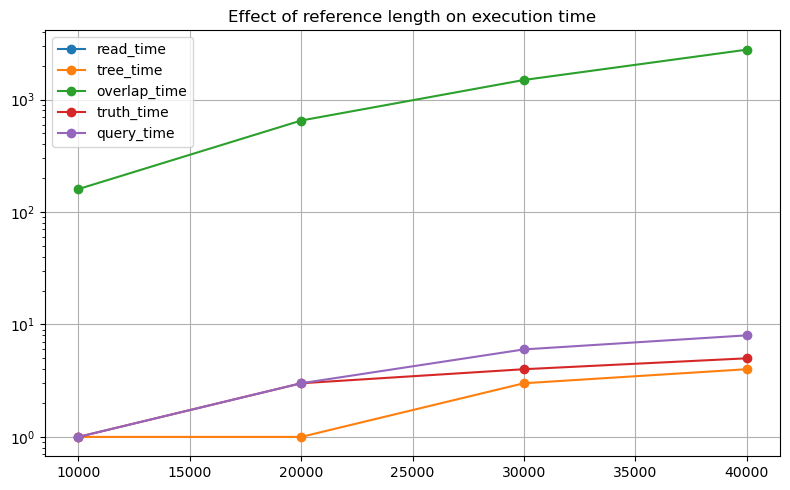

In [6]:
plt.figure(figsize=(8,5))
for col in ["read_time", "tree_time", "overlap_time", "truth_time", "query_time"]:
    plt.plot(df["truncate_ref_len"], df[col], marker="o", label=col)

plt.yscale("log")
plt.title("Effect of reference length on execution time")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("./fig/sweep_time_truncate_ref_len.png")
plt.show()

# anchor 数量

## anchor 总数

In [2]:
# 可执行程序路径
EXECUTABLE = "../anchor_mapping"

# sweep 范围（你可以改成别的参数 sweep）
anchor_values = range(2, 100, 5)

results = []

for n in anchor_values:
    print(f"Running with num_anchors = {n}...")
    # 调用你的程序
    cmd = [
        EXECUTABLE,
        "--num_anchors", str(n),
        "--truncate_ref_len", "10000",
        "--anchor_len", "20",
        "--num_queries", "100",
        "--maxDist", "3",
    ]
    proc = subprocess.run(cmd, capture_output=True, text=True)

    if proc.returncode != 0:
        print(f"Error running {cmd}: {proc.stderr}")
        continue

    output = proc.stdout

    # 提取平均指标
    metrics = {}
    patterns = {
        "avg_tp":       r"Average TP:\s*([0-9.eE+-]+)",
        "avg_fp":       r"Average FP:\s*([0-9.eE+-]+)",
        "avg_fn":       r"Average FN:\s*([0-9.eE+-]+)",
        "avg_recall":   r"Average Recall:\s*([0-9.eE+-]+)",
        "avg_precision":r"Average Precision:\s*([0-9.eE+-]+)",
    }

    for key, pat in patterns.items():
        m = re.search(pat, output)
        if m:
            metrics[key] = float(m.group(1))
        else:
            print(f"⚠️ {key} not found in output for num_anchors={n}")
            metrics[key] = None

    metrics["num_anchors"] = n
    results.append(metrics)

# 转 DataFrame
df = pd.DataFrame(results)
print(df)

# 保存结果
df.to_csv("./csv/sweep_results_anchor_full.csv", index=False)

# 画图
plt.plot(df["num_anchors"], df["avg_precision"], marker="o")
plt.xlabel("Number of anchors")
plt.ylabel("Average Precision")
plt.title("Effect of num_anchors on Precision")
plt.grid(True)
plt.savefig("./fig/sweep_precision_anchor_full.png")
plt.show()

Running with num_anchors = 2...
Running with num_anchors = 7...
Running with num_anchors = 12...
Running with num_anchors = 17...
Running with num_anchors = 22...
Running with num_anchors = 27...


KeyboardInterrupt: 

Running with num_anchors = 0...
Error running ['../anchor_mapping', '--num_anchors', '0', '--truncate_ref_len', '10000', '--anchor_len', '20', '--num_queries', '100', '--maxDist', '3', '--auto_gen', 'true']: 

stack trace:
  0          [0x408192]  ../anchor_mapping()
  1    [0x7fa349d11090]  /lib/x86_64-linux-gnu/libc.so.6(+0x43090)
  2          [0x4348c1]  ../anchor_mapping()
  3    [0x7fa349cf2083]  __libc_start_main + 0xf3
  4          [0x40647e]  ../anchor_mapping()


Running with num_anchors = 1000...
Running with num_anchors = 2000...
Running with num_anchors = 3000...
Running with num_anchors = 4000...
Running with num_anchors = 5000...
Running with num_anchors = 6000...
Running with num_anchors = 7000...
   avg_tp  avg_fp  avg_fn  avg_recall  avg_precision  num_anchors
0    0.96    0.41    2.07    0.316832       0.700730         1000
1    1.32    0.51    1.68    0.440000       0.721311         2000
2    1.95    0.68    1.05    0.650000       0.741445         3000
3    2.43    0

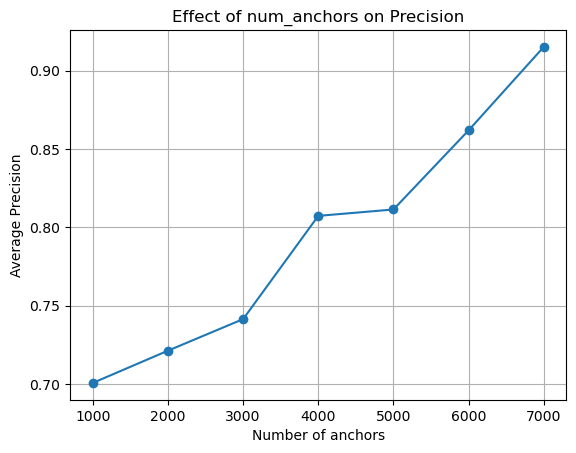

In [ ]:
# 可执行程序路径
EXECUTABLE = "../anchor_mapping"

# sweep 范围（你可以改成别的参数 sweep）
anchor_values = range(1000, 8000, 1000)

results = []

for n in anchor_values:
    print(f"Running with num_anchors = {n}...")
    # 调用你的程序
    cmd = [
        EXECUTABLE,
        "--num_anchors", str(n),
        "--truncate_ref_len", "10000",
        "--anchor_len", "20",
        "--num_queries", "100",
        "--maxDist", "3",
        "--auto_gen", "true",
    ]
    proc = subprocess.run(cmd, capture_output=True, text=True)

    if proc.returncode != 0:
        print(f"Error running {cmd}: {proc.stderr}")
        continue

    output = proc.stdout


    # 提取平均指标
    metrics = {}
    patterns = {
        "avg_tp":       r"Average TP:\s*([0-9.eE+-]+)",
        "avg_fp":       r"Average FP:\s*([0-9.eE+-]+)",
        "avg_fn":       r"Average FN:\s*([0-9.eE+-]+)",
        "avg_recall":   r"Average Recall:\s*([0-9.eE+-]+)",
        "avg_precision":r"Average Precision:\s*([0-9.eE+-]+)",
    }

    for key, pat in patterns.items():
        m = re.search(pat, output)
        if m:
            metrics[key] = float(m.group(1))
        else:
            print(f"⚠️ {key} not found in output for num_anchors={n}")
            metrics[key] = None

    metrics["num_anchors"] = n
    results.append(metrics)

# 转 DataFrame
df = pd.DataFrame(results)
print(df)

# 保存结果
df.to_csv("./csv/sweep_results_anchor_full.csv", index=False)

# 画图
plt.plot(df["num_anchors"], df["avg_precision"], marker="o", label='precision')
plt.plot(df["num_anchors"], df["avg_recall"], marker=".", label='recall')
plt.xlabel("Number of anchors")
plt.ylabel("Average Precision")
plt.title("Effect of num_anchors on Precision")
plt.legend()
plt.grid(True)
plt.savefig("./fig/sweep_precision_anchor_full.png")
plt.show()

In [1]:
import subprocess
import re
import pandas as pd
import os

# 可执行程序路径
EXECUTABLE = "../anchor_mapping"

# sweep 范围（你可以改成别的参数 sweep）
error_values = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]

results = []

for n in error_values:
    print(f"Running with maxDist = {n}...")
    # 调用你的程序
    cmd = [
        EXECUTABLE,
        "--num_anchors", "1000",
        "--truncate_ref_len", "10000",
        "--anchor_len", "20",
        "--num_queries", "100",
        "--maxDist", str(n),
    ]
    proc = subprocess.run(cmd, capture_output=True, text=True)

    if proc.returncode != 0:
        print(f"Error running {cmd}: {proc.stderr}")
        continue

    output = proc.stdout

    # --- 提取 split stats ---
    pattern = re.compile(
        r"---- Split stats ----\s*"
        r"Total points:\s*([0-9]+)\s*"
        r"First partition:\s*([0-9]+)\s*"
        r"Second partition:\s*([0-9]+)\s*"
        r"Cross to second:\s*([0-9]+)\s*"
        r"Cross to first:\s*([0-9]+)\s*"
        r"---------------------",
        re.MULTILINE
    )

    results = []
    for m in pattern.finditer(output):
        stats = {
            "total_points": int(m.group(1)),
            "first_partition": int(m.group(2)),
            "second_partition": int(m.group(3)),
            "cross_to_second": int(m.group(4)),
            "cross_to_first": int(m.group(5)),
        }
        results.append(stats)

    # --- 转 DataFrame ---
    df = pd.DataFrame(results)
    df["max_dist"] = n  # 添加当前参数列

    # --- 保存为单独 CSV 文件 ---
    csv_path = f"./csv/split_stats_max_dists_{n}.csv"
    df.to_csv(csv_path, index=False)
    print(f"Saved {csv_path}, {len(df)} rows")


Running with maxDist = 1...
Saved ./csv/split_stats_max_dists_1.csv, 7525 rows
Running with maxDist = 2...
Saved ./csv/split_stats_max_dists_2.csv, 7525 rows
Running with maxDist = 3...
Saved ./csv/split_stats_max_dists_3.csv, 7525 rows
Running with maxDist = 4...
Saved ./csv/split_stats_max_dists_4.csv, 7525 rows
Running with maxDist = 5...
Saved ./csv/split_stats_max_dists_5.csv, 7525 rows
Running with maxDist = 6...
Saved ./csv/split_stats_max_dists_6.csv, 7525 rows
Running with maxDist = 7...
Saved ./csv/split_stats_max_dists_7.csv, 7525 rows
Running with maxDist = 8...
Saved ./csv/split_stats_max_dists_8.csv, 7525 rows
Running with maxDist = 9...
Saved ./csv/split_stats_max_dists_9.csv, 7525 rows
Running with maxDist = 10...
Saved ./csv/split_stats_max_dists_10.csv, 7525 rows
Running with maxDist = 11...
Saved ./csv/split_stats_max_dists_11.csv, 7525 rows
Running with maxDist = 12...
Saved ./csv/split_stats_max_dists_12.csv, 7525 rows
Running with maxDist = 13...
Saved ./csv/split

KeyboardInterrupt: 

In [2]:
import pandas as pd

def compute_mean_overlap_ratio(csv_path: str) -> float:
    """
    从 CSV 文件计算平均 overlap 比例。
    overlap = cross_to_second + cross_to_first
    total = total_points
    返回 overlap/total 的平均值。
    """
    df = pd.read_csv(csv_path)

    # 检查是否包含需要的列
    required_cols = {"cross_to_second", "cross_to_first", "total_points"}
    if not required_cols.issubset(df.columns):
        raise ValueError(f"CSV 缺少必要列: {required_cols - set(df.columns)}")

    # 计算 overlap 比例
    df["overlap_ratio"] = (df["cross_to_second"] + df["cross_to_first"]) / df["total_points"]

    # 求平均值
    mean_ratio = df["overlap_ratio"].mean()

    print(f"{csv_path}: mean overlap ratio = {mean_ratio:.4f}")
    return mean_ratio


In [3]:
mean_ratio = compute_mean_overlap_ratio("./csv/split_stats_num_anchors_500.csv")

./csv/split_stats_num_anchors_500.csv: mean overlap ratio = 0.4686


# 允许的 error 范围

Running with maxDist = 1...
Running with maxDist = 2...
Running with maxDist = 3...
Running with maxDist = 4...
Running with maxDist = 5...
Running with maxDist = 6...
Running with maxDist = 7...
Running with maxDist = 8...
Running with maxDist = 9...
Running with maxDist = 10...
Running with maxDist = 11...
Running with maxDist = 12...
Running with maxDist = 13...
Running with maxDist = 14...
Running with maxDist = 15...
Running with maxDist = 16...
Running with maxDist = 17...
Running with maxDist = 18...
Running with maxDist = 19...
Running with maxDist = 20...
     avg_tp  avg_fp  avg_fn  avg_recall  avg_precision  maxDist
0      1.00     0.0     0.0         1.0            1.0        1
1      3.00     0.0     0.0         1.0            1.0        2
2      3.00     0.0     0.0         1.0            1.0        3
3      5.06     0.0     0.0         1.0            1.0        4
4      5.41     0.0     0.0         1.0            1.0        5
5      9.86     0.0     0.0         1.0      

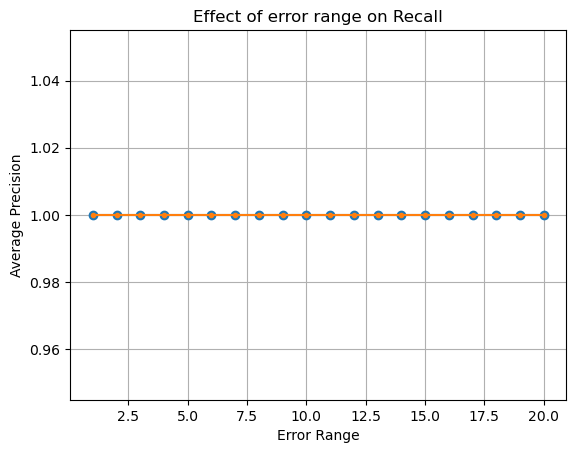

In [2]:
# 可执行程序路径
EXECUTABLE = "../anchor_mapping"

# sweep 范围（你可以改成别的参数 sweep）
error_values = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]

results = []

for n in error_values:
    print(f"Running with maxDist = {n}...")
    # 调用你的程序
    cmd = [
        EXECUTABLE,
        "--num_anchors", "1000",
        "--truncate_ref_len", "10000",
        "--anchor_len", "20",
        "--num_queries", "100",
        "--maxDist", str(n),
    ]
    proc = subprocess.run(cmd, capture_output=True, text=True)

    if proc.returncode != 0:
        print(f"Error running {cmd}: {proc.stderr}")
        continue

    output = proc.stdout

    # 提取平均指标
    metrics = {}
    patterns = {
        "avg_tp":       r"Average TP:\s*([0-9.eE+-]+)",
        "avg_fp":       r"Average FP:\s*([0-9.eE+-]+)",
        "avg_fn":       r"Average FN:\s*([0-9.eE+-]+)",
        "avg_recall":   r"Average Recall:\s*([0-9.eE+-]+)",
        "avg_precision":r"Average Precision:\s*([0-9.eE+-]+)",
    }

    for key, pat in patterns.items():
        m = re.search(pat, output)
        if m:
            metrics[key] = float(m.group(1))
        else:
            print(f"⚠️ {key} not found in output for maxDist={n}")
            metrics[key] = None

    metrics["maxDist"] = n
    results.append(metrics)

# 转 DataFrame
df = pd.DataFrame(results)
print(df)

# 保存结果
df.to_csv("./csv/sweep_results_max_dist.csv", index=False)

# 画图
plt.plot(df["maxDist"], df["avg_precision"], marker="o")
plt.plot(df["maxDist"], df["avg_recall"], marker=".")
plt.xlabel("Error Range")
plt.ylabel("Average Precision")
plt.title("Effect of error range on Recall")
# plt.legend()
plt.grid(True)
plt.savefig("./fig/sweep_precision_max_dist.png")
plt.show()

# anchor距离（滑窗，从近到远稳定 20 个）

In [ ]:
import subprocess
import re
import pandas as pd
import matplotlib.pyplot as plt
import os

# 可执行程序路径
EXECUTABLE = "../anchor_mapping"

# sweep 范围：start_idx, end_idx
idx_ranges = [(i, i+10) for i in range(0, 100, 10)]


results = []

for start_idx, end_idx in idx_ranges:
    print(f"Running with start_idx={start_idx}, end_idx={end_idx} ...")
    
    # 调用你的程序
    cmd = [
        EXECUTABLE,
        "--num_anchors", "1000",
        "--truncate_ref_len", "10000",
        "--anchor_len", "20",
        "--num_queries", "100",
        "--use_all", "false",
        "--start_idx", str(start_idx),
        "--end_idx", str(end_idx),
    ]
    proc = subprocess.run(cmd, capture_output=True, text=True)

    if proc.returncode != 0:
        print(f"Error running {cmd}: {proc.stderr}")
        continue

    output = proc.stdout

    # 提取平均指标
    metrics = {}
    patterns = {
        "avg_tp":        r"Average TP:\s*([0-9.eE+-]+)",
        "avg_fp":        r"Average FP:\s*([0-9.eE+-]+)",
        "avg_fn":        r"Average FN:\s*([0-9.eE+-]+)",
        "avg_recall":    r"Average Recall:\s*([0-9.eE+-]+)",
        "avg_precision": r"Average Precision:\s*([0-9.eE+-]+)",
    }

    for key, pat in patterns.items():
        m = re.search(pat, output)
        if m:
            metrics[key] = float(m.group(1))
        else:
            print(f"⚠️ {key} not found in output for idx=({start_idx},{end_idx})")
            metrics[key] = None

    metrics["start_idx"] = start_idx
    metrics["end_idx"] = end_idx
    results.append(metrics)

# 转 DataFrame
df = pd.DataFrame(results)
print(df)

# 确保输出目录存在
os.makedirs("./csv", exist_ok=True)
os.makedirs("./fig", exist_ok=True)

# 保存结果
df.to_csv("./csv/sweep_results_idx.csv", index=False)

# 画图
x_labels = [f"{s}-{e}" for s,e in zip(df["start_idx"], df["end_idx"])]
plt.plot(x_labels, df["avg_precision"], marker="o")
plt.xlabel("idx range")
plt.ylabel("Average Precision")
plt.title("Effect of idx range on Precision")
plt.grid(True)
plt.savefig("./fig/sweep_precision_idx.png")
plt.show()

Running with start_idx=0, end_idx=10 ...


Error running ['../anchor_mapping', '--num_anchors', '1000', '--truncate_ref_len', '10000', '--anchor_len', '20', '--num_queries', '100', '--use_all', 'false', '--start_idx', '0', '--end_idx', '10']: 

stack trace:
  0          [0x406ff2]  ../anchor_mapping()
  1    [0x7fb299ec0090]  /lib/x86_64-linux-gnu/libc.so.6(+0x43090)
  2    [0x7fb29a29a5c0]  std::_Hash_bytes(void const*, unsigned long, unsigned long) + 0x30
  3          [0x422afc]  ../anchor_mapping()
  4          [0x42375b]  ../anchor_mapping()
  5          [0x4319a4]  ../anchor_mapping()
  6    [0x7fb299ea1083]  __libc_start_main + 0xf3
  7          [0x4052de]  ../anchor_mapping()


Running with start_idx=10, end_idx=20 ...
Error running ['../anchor_mapping', '--num_anchors', '1000', '--truncate_ref_len', '10000', '--anchor_len', '20', '--num_queries', '100', '--use_all', 'false', '--start_idx', '10', '--end_idx', '20']: 

stack trace:
  0          [0x406ff2]  ../anchor_mapping()
  1    [0x7fc4b3554090]  /lib/x86_64-linux-gnu

KeyError: 'start_idx'

# anchor 从近到远的 elbow（选前 n 个）

Running with start_idx=0.000000, end_idx=1.000000 ...
Running with start_idx=0.000000, end_idx=2.000000 ...
Running with start_idx=0.000000, end_idx=3.000000 ...
Running with start_idx=0.000000, end_idx=4.000000 ...
Running with start_idx=0.000000, end_idx=5.000000 ...
Running with start_idx=0.000000, end_idx=6.000000 ...
Running with start_idx=0.000000, end_idx=7.000000 ...
Running with start_idx=0.000000, end_idx=8.000000 ...
Running with start_idx=0.000000, end_idx=9.000000 ...
Running with start_idx=0.000000, end_idx=10.000000 ...
Running with start_idx=0.000000, end_idx=11.000000 ...
Running with start_idx=0.000000, end_idx=12.000000 ...
Running with start_idx=0.000000, end_idx=13.000000 ...
Running with start_idx=0.000000, end_idx=14.000000 ...
Running with start_idx=0.000000, end_idx=15.000000 ...
Running with start_idx=0.000000, end_idx=16.000000 ...
Running with start_idx=0.000000, end_idx=17.000000 ...
Running with start_idx=0.000000, end_idx=18.000000 ...
Running with start_

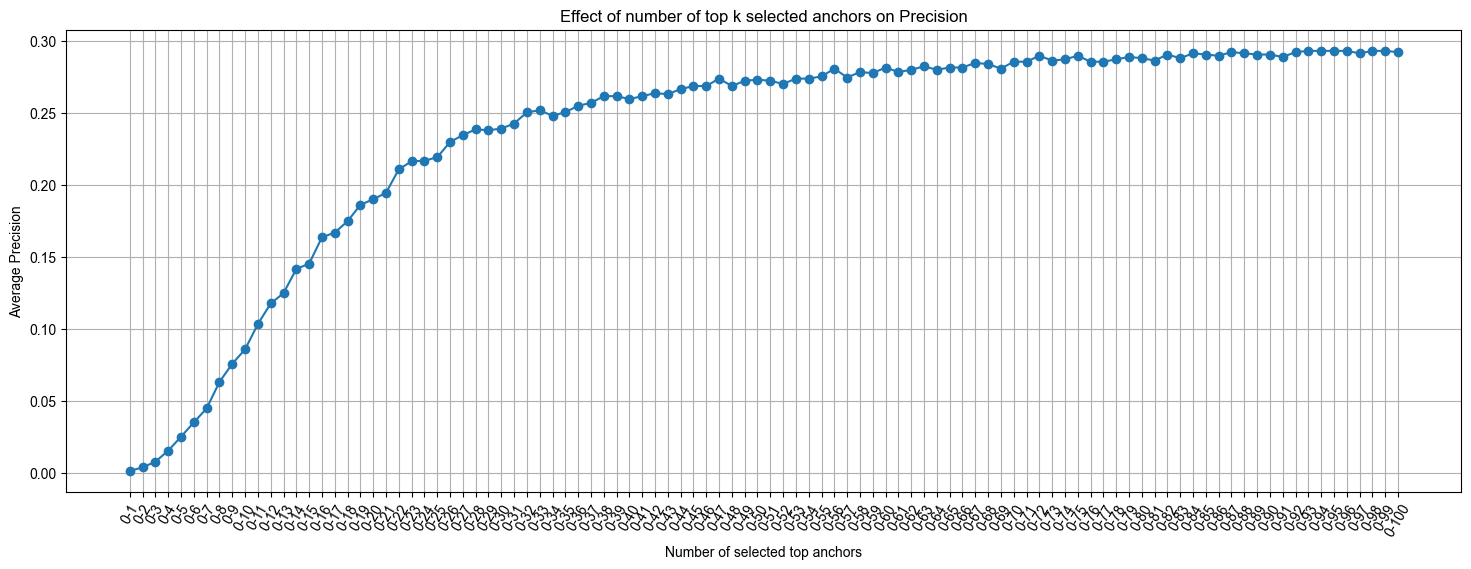

In [20]:
# 可执行程序路径
EXECUTABLE = "../anchor_mapping"

num_anchors = 1000  # 用于计算选中 anchor 数量

# sweep 范围：start_idx, end_idx
frac_ranges = [(0, i) for i in range(1, 101)]

results = []

for start_idx, end_idx in frac_ranges:
    print(f"Running with start_idx={f"{start_idx:.6f}"}, end_idx={f"{end_idx:.6f}"} ...")
    
    cmd = [
        EXECUTABLE,
        "--num_anchors", str(num_anchors),
        "--truncate_ref_len", "10000",
        "--anchor_len", "20",
        "--num_queries", "100",
        "--use_all", "false",
        "--start_idx", str(f"{start_idx:.6f}"),
        "--end_idx", str(f"{end_idx:.6f}"),
        "--method", "anchor",
        "--auto_gen", "true"
    ]
    proc = subprocess.run(cmd, capture_output=True, text=True)

    if proc.returncode != 0:
        print(f"Error running {cmd}: {proc.stderr}")
        continue

    output = proc.stdout

    metrics = {}
    patterns = {
        "avg_tp":        r"Average TP:\s*([0-9.eE+-]+)",
        "avg_fp":        r"Average FP:\s*([0-9.eE+-]+)",
        "avg_fn":        r"Average FN:\s*([0-9.eE+-]+)",
        "avg_recall":    r"Average Recall:\s*([0-9.eE+-]+)",
        "avg_precision": r"Average Precision:\s*([0-9.eE+-]+)",
        "end_idx": r"Start and end indexes: 0, \s*([0-9.eE+-]+)"
    }

    for key, pat in patterns.items():
        m = re.search(pat, output)
        if m:
            if m.group(1)=="-":
                continue
            metrics[key] = float(m.group(1))
        else:
            print(f"⚠️ {key} not found in output for idx=({start_idx},{end_idx})")
            metrics[key] = None

    metrics["start_idx"] = start_idx
    metrics["end_idx"] = end_idx
    metrics["selected_anchors"] = end_idx  # 新增一列
    results.append(metrics)

# 转 DataFrame
df = pd.DataFrame(results)
print(df)

os.makedirs("./csv", exist_ok=True)
os.makedirs("./fig", exist_ok=True)

df.to_csv("./csv/sweep_results_by_num_top_anchors.csv", index=False)

# 画图，用 selected_anchors 作为 x 轴
x_labels = [f"{s}-{e}" for s,e in zip(df["start_idx"], df["end_idx"])]
plt.figure(figsize=(18, 6))
plt.plot(x_labels, df["avg_precision"], marker="o")
plt.xlabel("Number of selected top anchors", )
plt.ylabel("Average Precision")
plt.xticks(rotation=60)
plt.title("Effect of number of top k selected anchors on Precision")
plt.grid(True)
plt.savefig("./fig/sweep_precision_by_num_top_anchors.png")
plt.show()

In [13]:
df_normal = df.copy()

Running with start_idx=0.0, end_idx=1 ...
Running with start_idx=0.0, end_idx=2 ...
Running with start_idx=0.0, end_idx=3 ...
Running with start_idx=0.0, end_idx=4 ...
Running with start_idx=0.0, end_idx=5 ...
Running with start_idx=0.0, end_idx=6 ...
Running with start_idx=0.0, end_idx=7 ...
Running with start_idx=0.0, end_idx=8 ...
Running with start_idx=0.0, end_idx=9 ...
Running with start_idx=0.0, end_idx=10 ...
Running with start_idx=0.0, end_idx=11 ...
Running with start_idx=0.0, end_idx=12 ...
Running with start_idx=0.0, end_idx=13 ...
Running with start_idx=0.0, end_idx=14 ...
Running with start_idx=0.0, end_idx=15 ...
Running with start_idx=0.0, end_idx=16 ...
Running with start_idx=0.0, end_idx=17 ...
Running with start_idx=0.0, end_idx=18 ...
Running with start_idx=0.0, end_idx=19 ...
Running with start_idx=0.0, end_idx=20 ...
Running with start_idx=0.0, end_idx=21 ...
Running with start_idx=0.0, end_idx=22 ...
Running with start_idx=0.0, end_idx=23 ...
Running with start_i

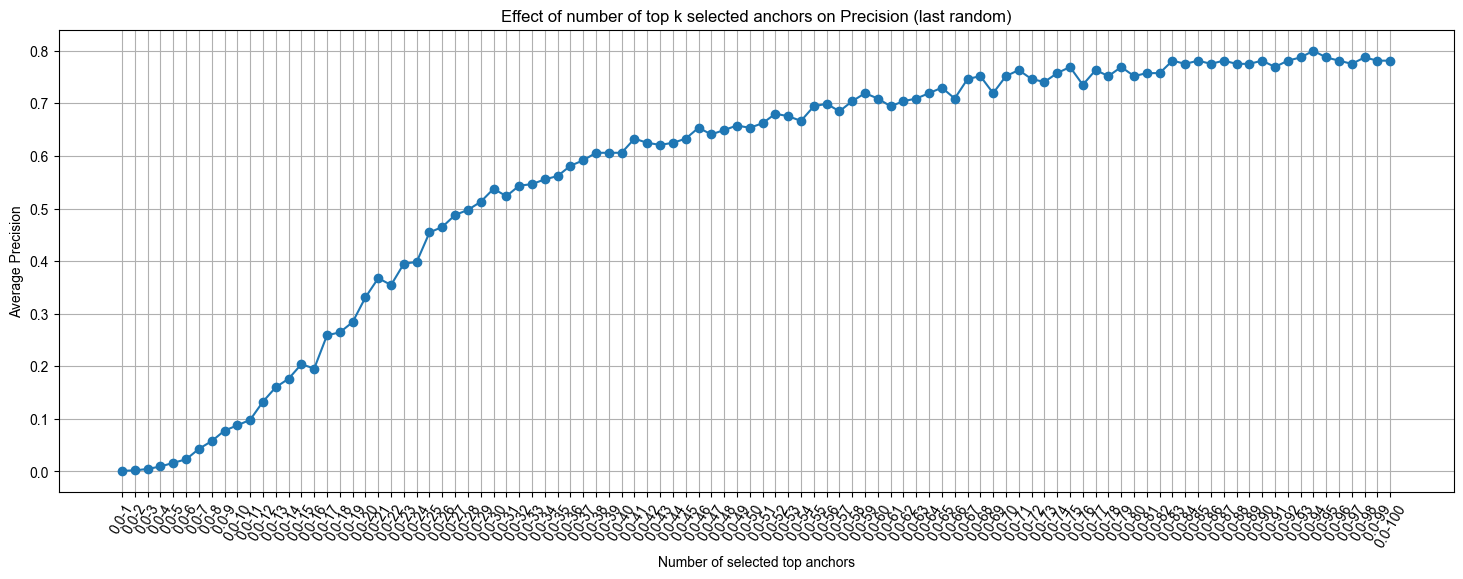

In [15]:
# 可执行程序路径
EXECUTABLE = "../anchor_mapping"

num_anchors = 1000  # 用于计算选中 anchor 数量

# sweep 范围：start_idx, end_idx
frac_ranges = [(0.0, i) for i in range(1, 101)]

results = []

for start_idx, end_idx in frac_ranges:
    print(f"Running with start_idx={start_idx}, end_idx={end_idx} ...")
    cmd = [
        EXECUTABLE,
        "--num_anchors", str(num_anchors),
        "--truncate_ref_len", "10000",
        "--anchor_len", "20",
        "--num_queries", "100",
        "--use_all", "false",
        "--start_idx", str(start_idx),
        "--end_idx", str(end_idx),
        "--method", "anchor",
        "--auto_gen", "true",
        "--last_random", "true"
    ]
    proc = subprocess.run(cmd, capture_output=True, text=True)

    if proc.returncode != 0:
        print(f"Error running {cmd}: {proc.stderr}")
        continue

    output = proc.stdout

    metrics = {}
    patterns = {
        "avg_tp":        r"Average TP:\s*([0-9.eE+-]+)",
        "avg_fp":        r"Average FP:\s*([0-9.eE+-]+)",
        "avg_fn":        r"Average FN:\s*([0-9.eE+-]+)",
        "avg_recall":    r"Average Recall:\s*([0-9.eE+-]+)",
        "avg_precision": r"Average Precision:\s*([0-9.eE+-]+)",
    }

    for key, pat in patterns.items():
        m = re.search(pat, output)
        if m:
            metrics[key] = float(m.group(1))
        else:
            print(f"⚠️ {key} not found in output for idx=({start_idx},{end_idx})")
            metrics[key] = None

    metrics["start_idx"] = start_idx
    metrics["end_idx"] = end_idx
    metrics["selected_anchors"] = end_idx  # 新增一列
    results.append(metrics)

# 转 DataFrame
df = pd.DataFrame(results)
print(df)

os.makedirs("./csv", exist_ok=True)
os.makedirs("./fig", exist_ok=True)

df.to_csv("./csv/sweep_results_by_num_top_anchors_last_random.csv", index=False)

# 画图，用 selected_anchors 作为 x 轴
plt.figure(figsize=(18, 6))
x_labels = [f"{s}-{e}" for s,e in zip(df["start_idx"], df["end_idx"])]
plt.plot(x_labels, df["avg_precision"], marker="o")
plt.xlabel("Number of selected top anchors")
plt.ylabel("Average Precision")
plt.xticks(rotation=60)
plt.title("Effect of number of top k selected anchors on Precision (last random)")
plt.grid(True)
plt.savefig("./fig/sweep_precision_by_num_top_anchors_last_random.png")
plt.show()

In [16]:
df_random = df.copy()

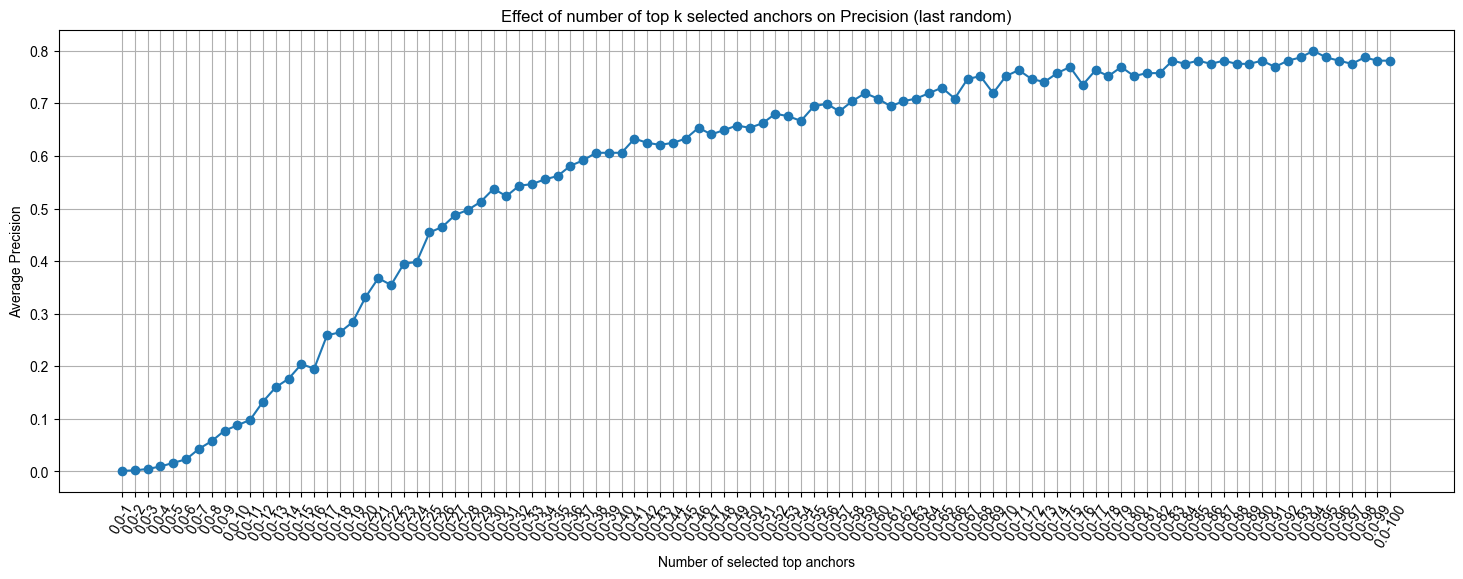

In [17]:
df = df_random
# 画图，用 selected_anchors 作为 x 轴
plt.figure(figsize=(18, 6))
x_labels = [f"{s}-{e}" for s,e in zip(df["start_idx"], df["end_idx"])]
plt.plot(x_labels, df["avg_precision"], marker="o")
plt.xlabel("Number of selected top anchors")
plt.ylabel("Average Precision")
plt.xticks(rotation=60)
plt.title("Effect of number of top k selected anchors on Precision (last random)")
plt.grid(True)
plt.savefig("./fig/sweep_precision_by_num_top_anchors_last_random.png")
plt.show()

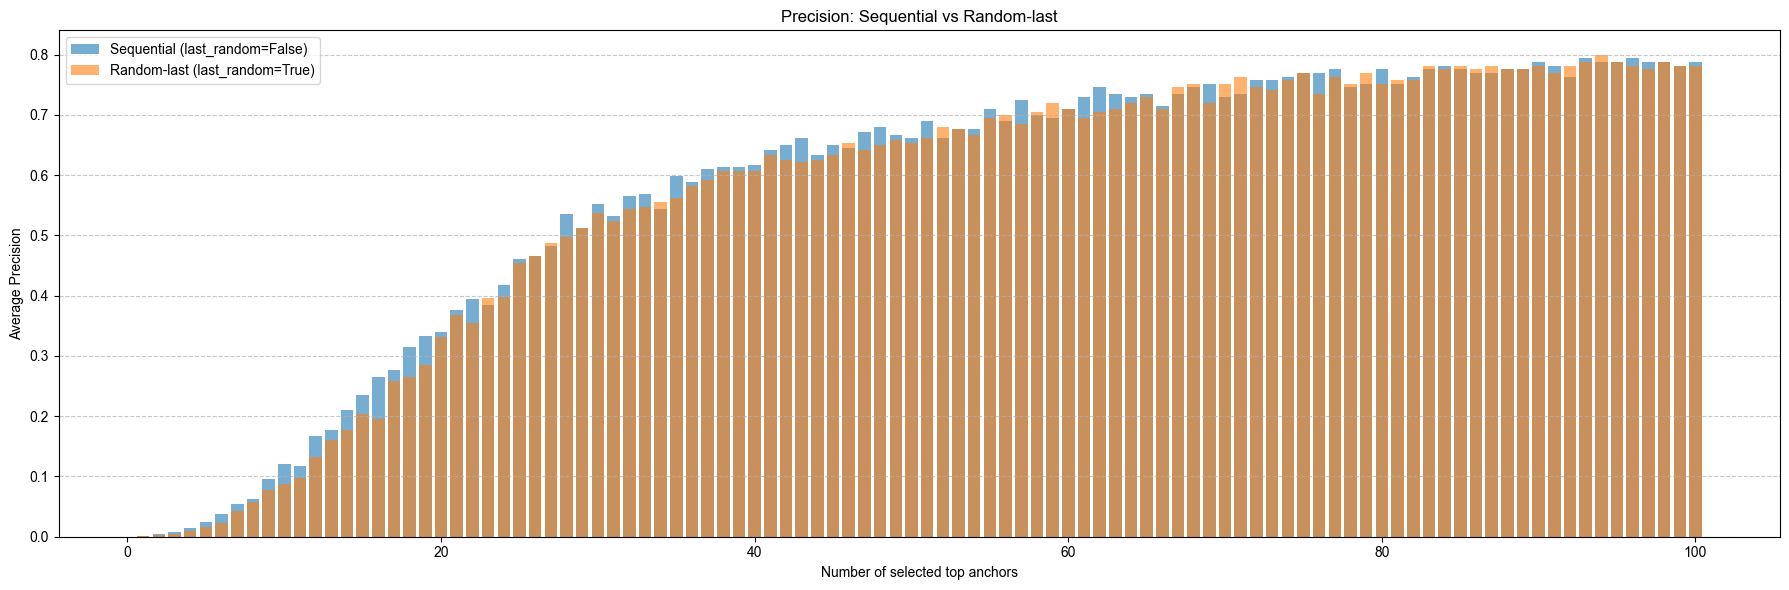

In [18]:
x = df_normal["selected_anchors"].values
y_normal = df_normal["avg_precision"].values
y_random = df_random["avg_precision"].values

plt.figure(figsize=(18,6))
plt.bar(x, y_normal, alpha=0.6, label="Sequential (last_random=False)")
plt.bar(x, y_random, alpha=0.6, label="Random-last (last_random=True)")

plt.xlabel("Number of selected top anchors")
plt.ylabel("Average Precision")
plt.title("Precision: Sequential vs Random-last")
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig("./fig/precision_overlap.png")
plt.show()

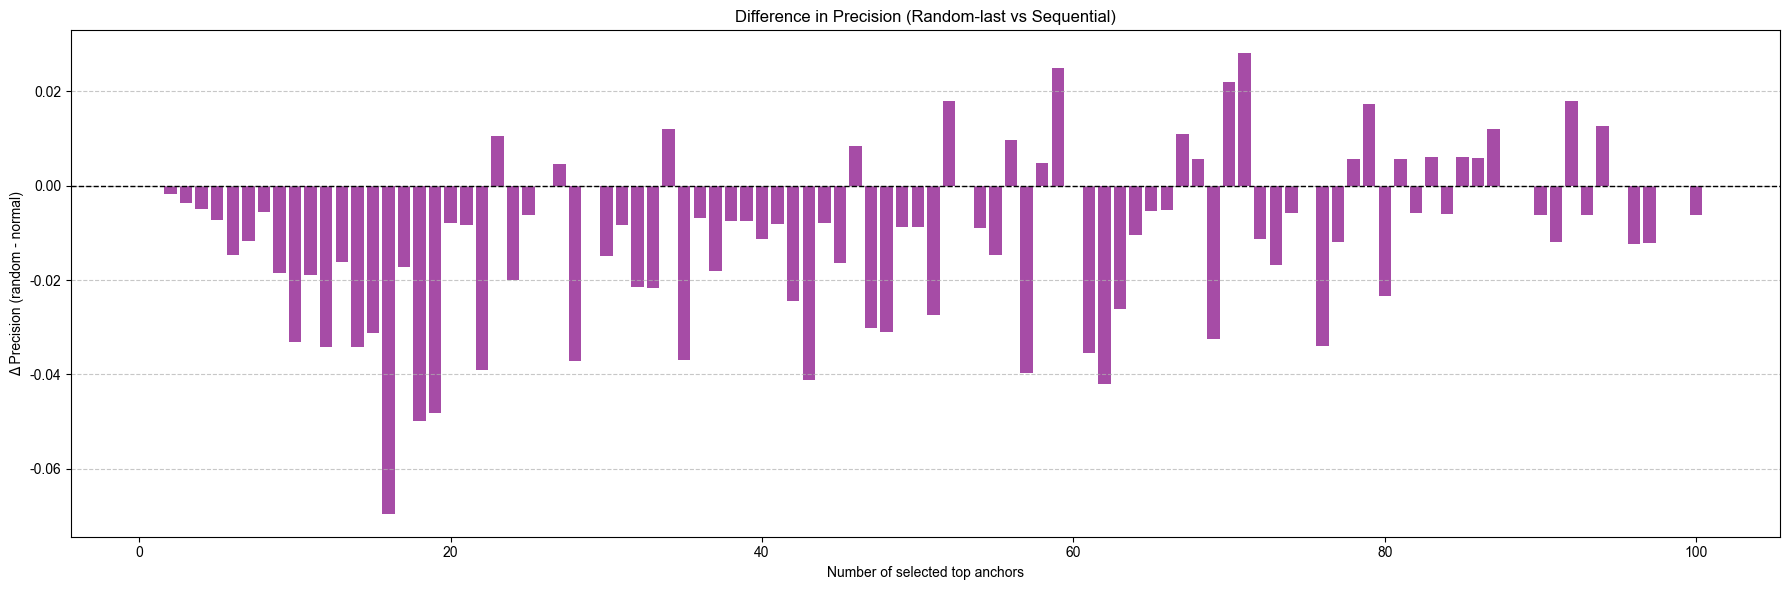

In [19]:
diff = y_random - y_normal

plt.figure(figsize=(18,6))
plt.bar(x, diff, color="purple", alpha=0.7)

plt.axhline(0, color="black", linewidth=1, linestyle="--")
plt.xlabel("Number of selected top anchors")
plt.ylabel("Δ Precision (random - normal)")
plt.title("Difference in Precision (Random-last vs Sequential)")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig("./fig/precision_difference.png")
plt.show()

# FP/FN

## seed-and-extend: seed length

In [2]:
# 可执行程序路径
EXECUTABLE = "../anchor_mapping"

In [4]:
# 设置支持中文和负号的字体 (可选，如果您的系统支持)
plt.rcParams['font.sans-serif'] = ['SimHei', 'Arial'] 
plt.rcParams['axes.unicode_minus'] = False 

# --- 脚本配置 ---
# 可执行程序路径
EXECUTABLE = "../anchor_mapping"

# 定义通用的 Accesses 提取模式
ACCESS_PATTERNS = {
    "index_accesses":    r"Index accesses:\s*([0-9]+)",
    "candidate_accesses":r"Candidate accesses:\s*([0-9]+)",
}

def run_experiment(cmd, sweep_param_name, sweep_value, existing_patterns):
    """
    通用函数：运行程序，提取所有指标（包括 Accesses）。
    """
    print(f"Running with {sweep_param_name} = {sweep_value}...")
    
    # 组合所有需要提取的模式
    all_patterns = {**existing_patterns, **ACCESS_PATTERNS}
    metrics = {}

    try:
        proc = subprocess.run(cmd, capture_output=True, text=True, check=True)
    except subprocess.CalledProcessError as e:
        print(f"Error running {cmd}: Return code {e.returncode}. Stderr: {e.stderr}")
        return None
    except FileNotFoundError:
        print(f"Error: Executable not found at {EXECUTABLE}. Please check the path.")
        sys.exit(1)

    output = proc.stdout
    
    for key, pat in all_patterns.items():
        m = re.search(pat, output)
        if m:
            if m.group(1) == "-":
                continue
            if 'accesses' in key:
                # Accesses 数量为整数
                metrics[key] = int(m.group(1))
            else:
                metrics[key] = float(m.group(1))
        else:
            # 找不到指标时，设为 None (对 PR) 或 0 (对 Accesses)
            if 'accesses' in key:
                 print(f"⚠️ Access metric '{key}' not found for {sweep_param_name}={sweep_value}")
                 metrics[key] = 0
            else:
                 print(f"⚠️ {key} not found for {sweep_param_name}={sweep_value}")
                 metrics[key] = None

    metrics[sweep_param_name] = sweep_value 
    return metrics

def plot_accesses_stacked_bar(df, sweep_param_name, title_suffix, fig_path):
    """
    通用函数：绘制 Index/Candidate Accesses 堆叠柱状图。
    """
    if 'index_accesses' in df.columns and 'candidate_accesses' in df.columns:
        plt.figure(figsize=(10, 6))

        # 绘制 Index Accesses 柱状图 (底部)
        plt.bar(
            df[sweep_param_name],
            df["index_accesses"],
            width=df[sweep_param_name].diff().min() * 0.8 if len(df) > 1 else 1.5, # 动态调整柱子宽度
            label='Index Accesses',
            color='tab:blue'
        )

        # 绘制 Candidate Accesses 柱状图 (堆叠在 Index Accesses 之上)
        plt.bar(
            df[sweep_param_name],
            df["candidate_accesses"],
            width=df[sweep_param_name].diff().min() * 0.8 if len(df) > 1 else 1.5,
            bottom=df["index_accesses"], # 关键：使用 index_accesses 作为底部
            label='Candidate Accesses',
            color='tab:orange'
        )

        plt.xlabel(f"{sweep_param_name.replace('_', ' ').title()}")
        plt.ylabel("Total Accesses Count (Index + Candidate)")
        plt.title(f"Index and Candidate Accesses Sweep on {sweep_param_name.replace('_', ' ').title()} ({title_suffix})")
        plt.legend()
        plt.grid(axis='y', linestyle=':', alpha=0.7)

        # 设置 X 轴刻度，确保每个值都显示
        plt.xticks(df[sweep_param_name])
        plt.show()
        plt.savefig(fig_path)
        print(f"Accesses 堆叠柱状图已保存至: {fig_path}")
        # plt.show()
    else:
        print(f"\n⚠️ 缺失 Accesses 数据，无法生成 {title_suffix} 的堆叠柱状图。请检查程序输出。")
    plt.close() # 关闭图形，释放内存

Running with seed_len = 8...
Running with seed_len = 10...
Running with seed_len = 12...
Running with seed_len = 14...
Running with seed_len = 16...
Running with seed_len = 18...
Running with seed_len = 20...
Running with seed_len = 22...
Running with seed_len = 24...

--- SAE 结果 DataFrame ---
   avg_tp  avg_fp  avg_fn  avg_recall  avg_precision  index_accesses  \
0     1.0    3.55     2.0    0.333333       0.219780             800   
1     1.0    1.27     2.0    0.333333       0.440529             700   
2     1.0    1.03     2.0    0.333333       0.492611             700   
3     1.0    1.00     2.0    0.333333       0.500000             600   
4     1.0    1.00     2.0    0.333333       0.500000             500   
5     1.0    1.00     2.0    0.333333       0.500000             500   
6     1.0    1.00     2.0    0.333333       0.500000             400   
7     1.0    1.00     2.0    0.333333       0.500000             300   
8     1.0    1.00     2.0    0.333333       0.500000     

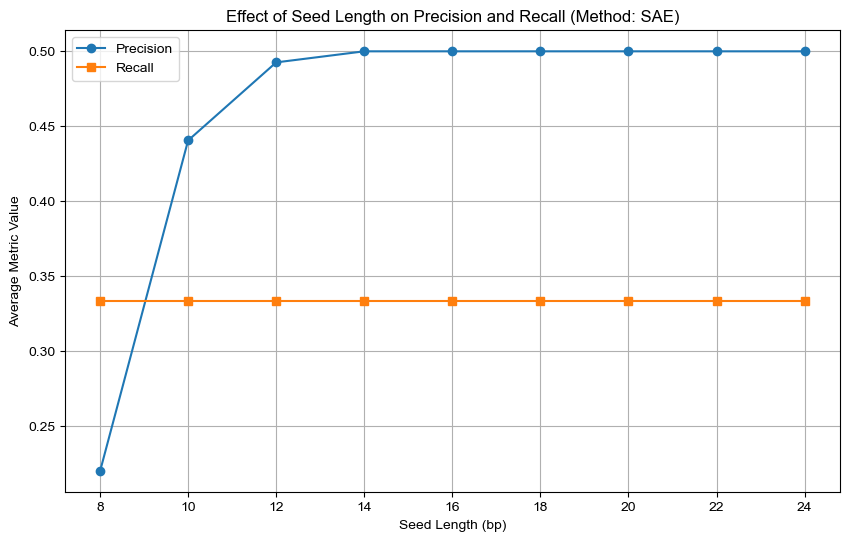

SAE Precision/Recall 图已保存至: ./fig/sweep_precision_recall_seed_len_sae.png


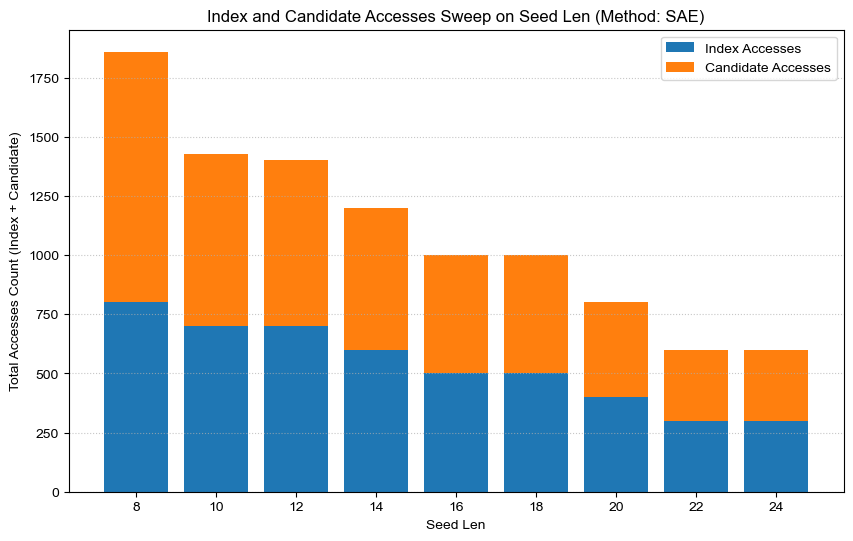

Accesses 堆叠柱状图已保存至: ./fig/sweep_accesses_seed_len_sae.png


In [ ]:
# =========================================================================
# === PART 1: Sweep maxDist (Method: SAE) ===
# =========================================================================

# sweep 范围：从 1 到 10，步长为 1 
maxDist_values = range(1, 11, 1) 
results_sae = []
sweep_param_sae = "maxDist"

# 提取 Precision/Recall 指标
sae_patterns = {
    "avg_tp":       r"Average TP:\s*([0-9.eE+-]+)",
    "avg_fp":       r"Average FP:\s*([0-9.eE+-]+)",
    "avg_fn":       r"Average FN:\s*([0-9.eE+-]+)",
    "avg_recall":   r"Average Recall:\s*([0-9.eE+-]+)",
    "avg_precision":r"Average Precision:\s*([0-9.eE+-]+)",
}

for maxDist in maxDist_values: # <-- 遍历 maxDist
    # 构建命令行参数
    cmd = [
        EXECUTABLE,
        "--truncate_ref_len", "10000",
        "--anchor_len", "30", 
        "--num_queries", "100",
        "--maxDist", str(maxDist),
        "--auto_gen", "true",
        "--method", "sae"
    ]
    
    metrics = run_experiment(cmd, sweep_param_sae, maxDist, sae_patterns) # <-- 传入 maxDist
    if metrics:
        results_sae.append(metrics)

# --- 数据处理与可视化 (SAE) ---
df_sae = pd.DataFrame(results_sae)
print("\n--- SAE 结果 DataFrame ---")
print(df_sae)

# 定义输出路径并确保目录存在
# 更改文件名以反映新的遍历参数 (maxDist)
csv_sae_path = "./csv/sweep_results_maxDist_sae.csv" 
fig_pr_sae_path = "./fig/sweep_precision_recall_maxDist_sae.png"
fig_access_sae_path = "./fig/sweep_accesses_maxDist_sae.png"

os.makedirs(os.path.dirname(csv_sae_path), exist_ok=True)
os.makedirs(os.path.dirname(fig_pr_sae_path), exist_ok=True)

# 保存结果
if not df_sae.empty:
    df_sae.to_csv(csv_sae_path, index=False)
    print(f"\nSAE 结果已保存至: {csv_sae_path}")

    # 绘图 1: Precision 和 Recall
    plt.figure(figsize=(10, 6))
    plt.plot(df_sae[sweep_param_sae], df_sae["avg_precision"], marker="o", label='Precision')
    plt.plot(df_sae[sweep_param_sae], df_sae["avg_recall"], marker="s", label='Recall') 
    plt.xlabel("Max Distance (Error Tolerance)") # <-- 更改 X 轴标签
    plt.ylabel("Average Metric Value")
    plt.title("Effect of Max Distance on Precision and Recall (Method: SAE)") # <-- 更改标题
    plt.legend()
    plt.grid(True)
    plt.show()
    plt.savefig(fig_pr_sae_path)
    print(f"SAE Precision/Recall 图已保存至: {fig_pr_sae_path}")
    plt.close()

    # 💥 绘图 2: Index/Candidate Accesses 堆叠柱状图 💥
    plot_accesses_stacked_bar(df_sae, sweep_param_sae, "Method: SAE", fig_access_sae_path)
else:
    print("SAE 实验结果为空，跳过保存和绘图。")

## anchor: anchor number

Running with num_anchors = 100...
Running with num_anchors = 200...
Running with num_anchors = 300...
Running with num_anchors = 400...
Running with num_anchors = 500...
Running with num_anchors = 600...
Running with num_anchors = 700...
Running with num_anchors = 800...
Running with num_anchors = 900...

--- Anchor 结果 DataFrame ---
   avg_tp  avg_fp  avg_fn  avg_recall  avg_precision  index_accesses  \
0     3.0    0.61     0.0         1.0       0.831025               0   
1     3.0    0.21     0.0         1.0       0.934579               0   
2     3.0    0.07     0.0         1.0       0.977199               0   
3     3.0    0.01     0.0         1.0       0.996678               0   
4     3.0    0.03     0.0         1.0       0.990099               0   
5     3.0    0.04     0.0         1.0       0.986842               0   
6     3.0    0.02     0.0         1.0       0.993377               0   
7     3.0    0.00     0.0         1.0       1.000000               0   
8     3.0    0.00

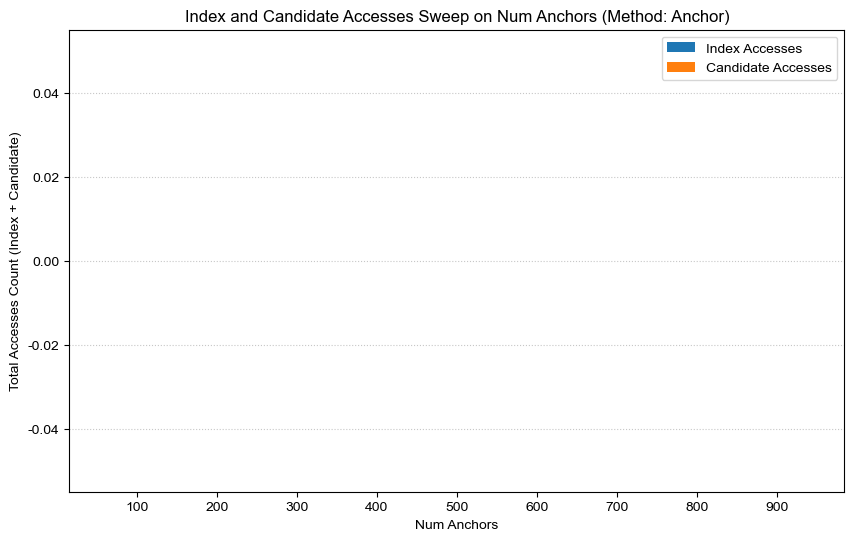

Accesses 堆叠柱状图已保存至: ./fig/sweep_accesses_num_anchors_anchor.png


In [ ]:
# =========================================================================
# === PART 2: Sweep num_anchors (Method: Anchor) ===
# =========================================================================

# sweep 范围
anchor_values = range(100, 1000, 100)
results_anchor = []
sweep_param_anchor = "num_anchors"

# 提取 Precision/Recall 指标
anchor_patterns = {
    "avg_tp":       r"Average TP:\s*([0-9.eE+-]+)",
    "avg_fp":       r"Average FP:\s*([0-9.eE+-]+)",
    "avg_fn":       r"Average FN:\s*([0-9.eE+-]+)",
    "avg_recall":   r"Average Recall:\s*([0-9.eE+-]+)",
    "avg_precision":r"Average Precision:\s*([0-9.eE+-]+)",
}

for n in anchor_values:
    # 调用你的程序
    cmd = [
        EXECUTABLE,
        "--num_anchors", str(n),
        "--truncate_ref_len", "10000",
        "--anchor_len", "30",
        "--anchor_radius", "30",
        "--num_queries", "100",
        "--maxDist", "3",
        "--auto_gen", "true",
        "--method", "anchor"
    ]
    
    metrics = run_experiment(cmd, sweep_param_anchor, n, anchor_patterns)
    if metrics:
        results_anchor.append(metrics)

# --- 数据处理与可视化 (Anchor) ---
df_anchor = pd.DataFrame(results_anchor)
print("\n--- Anchor 结果 DataFrame ---")
print(df_anchor)

# 定义输出路径并确保目录存在
csv_anchor_path = "./csv/sweep_results_anchor_full.csv"
fig_pr_anchor_path = "./fig/sweep_precision_anchor_full.png"
fig_access_anchor_path = "./fig/sweep_accesses_num_anchors_anchor.png" # 💥 新增

if not df_anchor.empty:
    # 保存结果
    df_anchor.to_csv(csv_anchor_path, index=False)
    print(f"\nAnchor 结果已保存至: {csv_anchor_path}")

    # 绘图 1: Precision 和 Recall (原图)
    plt.figure(figsize=(10, 6))
    plt.plot(df_anchor[sweep_param_anchor], df_anchor["avg_precision"], marker="o", label='Precision')
    plt.plot(df_anchor[sweep_param_anchor], df_anchor["avg_recall"], marker=".", label='Recall')
    plt.xlabel("Number of anchors")
    plt.ylabel("Average Precision/Recall")
    plt.title("Effect of num_anchors on Precision and Recall (Method: Anchor)")
    plt.legend()
    plt.grid(True)
    plt.show()
    plt.savefig(fig_pr_anchor_path)
    print(f"Anchor Precision/Recall 图已保存至: {fig_pr_anchor_path}")
    plt.close()

    # 💥 绘图 2: Index/Candidate Accesses 堆叠柱状图 💥
    plot_accesses_stacked_bar(df_anchor, sweep_param_anchor, "Method: Anchor", fig_access_anchor_path)
else:
    print("Anchor 实验结果为空，跳过保存和绘图。")

In [ ]:
# =========================================================================
# === PART 3: Sweep num_anchors (Method: mtree) ===
# =========================================================================

# sweep 范围
anchor_values = range(100, 200, 100)
results_anchor = []
sweep_param_anchor = "num_anchors"

# 提取 Precision/Recall 指标
anchor_patterns = {
    "avg_tp":       r"Average TP:\s*([0-9.eE+-]+)",
    "avg_fp":       r"Average FP:\s*([0-9.eE+-]+)",
    "avg_fn":       r"Average FN:\s*([0-9.eE+-]+)",
    "avg_recall":   r"Average Recall:\s*([0-9.eE+-]+)",
    "avg_precision":r"Average Precision:\s*([0-9.eE+-]+)",
}

for n in anchor_values:
    # 调用你的程序
    cmd = [
        EXECUTABLE,
        "--num_anchors", str(n),
        "--truncate_ref_len", "10000",
        "--anchor_len", "250",
        "--anchor_radius", "30",
        "--num_queries", "100",
        "--maxDist", "3",
        "--auto_gen", "false",
        "--method", "mtree",
        "--truncate_ref_len", "4641652",
        "--min_node_capacity", "1000",
        "--leaf_radius_threshold", "3000",
        "--compactness_min_capacity", "500",
        "--compactness_radius_factor", "10",
    ]
    
    metrics = run_experiment(cmd, sweep_param_anchor, n, anchor_patterns)
    if metrics:
        results_anchor.append(metrics)

# --- 数据处理与可视化 (Anchor) ---
df_anchor = pd.DataFrame(results_anchor)
print("\n--- Anchor 结果 DataFrame ---")
print(df_anchor)

# 定义输出路径并确保目录存在
csv_anchor_path = "./csv/sweep_results_anchor_full.csv"
fig_pr_anchor_path = "./fig/sweep_precision_anchor_full.png"
fig_access_anchor_path = "./fig/sweep_accesses_num_anchors_anchor.png" # 💥 新增

if not df_anchor.empty:
    # 保存结果
    df_anchor.to_csv(csv_anchor_path, index=False)
    print(f"\nAnchor 结果已保存至: {csv_anchor_path}")

    # 绘图 1: Precision 和 Recall (原图)
    plt.figure(figsize=(10, 6))
    plt.plot(df_anchor[sweep_param_anchor], df_anchor["avg_precision"], marker="o", label='Precision')
    plt.plot(df_anchor[sweep_param_anchor], df_anchor["avg_recall"], marker=".", label='Recall')
    plt.xlabel("Number of anchors")
    plt.ylabel("Average Precision/Recall")
    plt.title("Effect of num_anchors on Precision and Recall (Method: Anchor)")
    plt.legend()
    plt.grid(True)
    plt.show()
    plt.savefig(fig_pr_anchor_path)
    print(f"Anchor Precision/Recall 图已保存至: {fig_pr_anchor_path}")
    plt.close()

    # 💥 绘图 2: Index/Candidate Accesses 堆叠柱状图 💥
    plot_accesses_stacked_bar(df_anchor, sweep_param_anchor, "Method: Anchor", fig_access_anchor_path)
else:
    print("Anchor 实验结果为空，跳过保存和绘图。")

Running with num_anchors = 100...


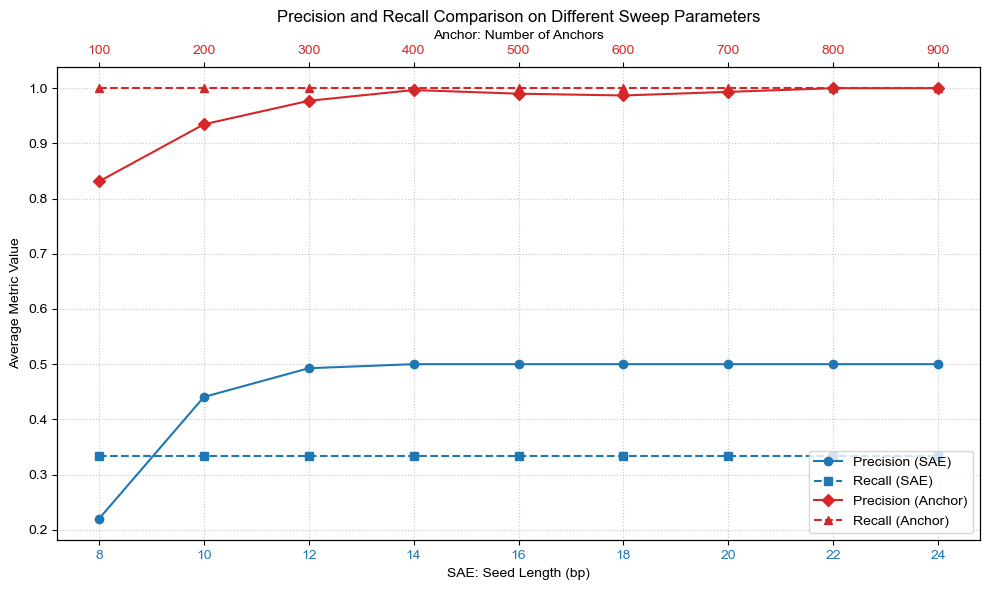

In [ ]:
csv_sae_path = "./csv/sweep_results_seed_len_sae.csv"
csv_anchor_path = "./csv/sweep_results_anchor_full.csv"

try:
    # 1. 读取 SAE 方法结果 (X轴: seed_len)
    df_sae = pd.read_csv(csv_sae_path)
    
    # 2. 读取 Anchor 方法结果 (X轴: num_anchors)
    df_anchor = pd.read_csv(csv_anchor_path)
    
except FileNotFoundError as e:
    print(f"错误：找不到文件 {e.filename}。请确认您已经运行了两个脚本并生成了相应的CSV文件。")
    # 如果文件找不到，则退出
    exit()

# --- 绘图：使用双 X 轴实现单图绘制 ---

plt.rcParams['font.sans-serif'] = ['SimHei', 'Arial'] # 支持中文显示
plt.rcParams['axes.unicode_minus'] = False # 解决负号显示问题

# 创建主图框和主轴 (左侧 Y 轴)
fig, ax1 = plt.subplots(figsize=(10, 6))

# --- 绘制 SAE 方法结果 (使用主 X 轴/底部 X 轴) ---
# X 轴: seed_len
ax1.plot(df_sae["seed_len"], df_sae["avg_precision"], marker="o", linestyle='-', color='tab:blue', label='Precision (SAE)')
ax1.plot(df_sae["seed_len"], df_sae["avg_recall"], marker="s", linestyle='--', color='tab:blue', label='Recall (SAE)')

ax1.set_xlabel("SAE: Seed Length (bp)") # 主 X 轴标签
ax1.set_ylabel("Average Metric Value")  # Y 轴标签
ax1.tick_params(axis='x', labelcolor='tab:blue') # 设置刻度颜色以区分

# --- 创建次 X 轴 (顶部 X 轴) 用于 Anchor 方法 ---
ax2 = ax1.twiny()

# --- 绘制 Anchor 方法结果 (使用次 X 轴/顶部 X 轴) ---
# X 轴: num_anchors
ax2.plot(df_anchor["num_anchors"], df_anchor["avg_precision"], marker="D", linestyle='-', color='tab:red', label='Precision (Anchor)')
ax2.plot(df_anchor["num_anchors"], df_anchor["avg_recall"], marker="^", linestyle='--', color='tab:red', label='Recall (Anchor)')

ax2.set_xlabel("Anchor: Number of Anchors") # 次 X 轴标签
ax2.tick_params(axis='x', labelcolor='tab:red') # 设置刻度颜色以区分

# --- 共同设置 ---
plt.title("Precision and Recall Comparison on Different Sweep Parameters") # 标题
ax1.grid(True, linestyle=':', alpha=0.7) # 网格线

# 合并所有图例（SAE 和 Anchor 的 4 条线）
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='lower right')

# 调整布局
fig.tight_layout() 
plt.show()

# Data Reuse

## seed-and-extend

## tree